# 2 — Preprocessing GPS MAID untuk OD Analysis Ring Road Utara

Pipeline preprocessing data MAID GPS untuk analisis Origin-Destination (OD)
6 simpang RRU. Mengikuti taksonomi 4-pilar dari Li et al. (2025) — *Trajectory
Data Preprocessing: Methods and Models* — dengan adaptasi untuk karakter MAID
(event-driven sampling, multi-app source, sensor fusion bursts).

## Stage overview
- **Stage 0** — Setup jaringan jalan RRU (OSMnx).
- **Stage 1a** — Bounding box + temporal filter, drop singleton MAID.
- **Stage 1b** — Snap candidate edge (R-tree), drop singleton MAID.
- **Stage 1c** — Bilocation handling (collapse spread kecil), drop singleton MAID.
- **Stage 2** — Trajectory segmentation. Tiga metode dijalankan untuk
  perbandingan sensitivitas; output utama dari **Zheng et al. 2011**.
  - Method A: **Zheng et al. 2011** — sequential greedy SPD (dual threshold).
  - Method B: **ST-DBSCAN** (Birant & Kut, 2007) — spatiotemporal density.
  - Method C: **Velocity-based dwell** (Schuessler & Axhausen, 2009) — kinematic.

> Setelah setiap operasi destruktif: re-apply *invariant restoration*
> (`drop_singleton_maids`, `drop_short_trips`) untuk menjaga konsistensi pipeline.

## Setup

In [1]:
from collections import Counter
from pathlib import Path
from typing import Callable

import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import polars as pl
import seaborn as sns
import shapely
from pyproj import Transformer
from shapely.strtree import STRtree


### Konstanta & path

In [2]:
# ---- I/O paths ----
INPUT_PARQUET = Path("./processed-data/all_gps_data_no_dup.parquet")
CACHE_DIR = Path("./cache")
PROCESSED_DIR = Path("./processed-data")

OUTPUT_BBOX = PROCESSED_DIR / "output_bbox.parquet"
OUTPUT_CANDIDATES = PROCESSED_DIR / "gps_rru_candidates.parquet"
OUTPUT_COLLAPSED = PROCESSED_DIR / "gps_rru_collapsed.parquet"
OUTPUT_TRIPS = PROCESSED_DIR / "gps_rru_trips.parquet"
OUTPUT_TRIPS_DBSCAN = PROCESSED_DIR / "gps_rru_trips_stdbscan.parquet"
OUTPUT_TRIPS_VELOCITY = PROCESSED_DIR / "gps_rru_trips_velocity.parquet"
OUTPUT_FINAL = PROCESSED_DIR / "gps_rru_final.parquet"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# ---- Spatial scope (WGS84) ----
LON_MIN, LON_MAX = 110.342299, 110.433240
LAT_MIN, LAT_MAX = -7.767411, -7.742002

EPSG_WGS84 = 4326
EPSG_UTM49S = 32749

MAX_DIST_METERS = 50

# ---- Temporal scope (Februari 2022, epoch seconds) ----
TS_START = 1643648400
TS_END = 1646067599

# ---- Stage 2: thresholds (shared across methods where comparable) ----
SPD_DIST_M = 100.0          # spatial radius / cluster eps  (Zheng dist_threshold)
SPD_TIME_MIN = 20.0         # min stay duration (Zheng time_threshold)
SPD_TIME_S = SPD_TIME_MIN * 60.0

# ST-DBSCAN specific
DBSCAN_MIN_PTS = 3

# Velocity-based specific
VELOCITY_THRESHOLD_MS = 1.5     # ~5.4 km/h, slow walk → dwell candidate
VELOCITY_SMOOTH_WINDOW = 3       # moving median window (odd)

MIN_PINGS_PER_TRIP = 3

# ---- Reference: 6 simpang RRU ----
SIMPANG_KRONGGAHAN = (-7.744769426425405, 110.34897889640796)
SIMPANG_JOMBOR = (-7.749221082422497, 110.36229833670288)
SIMPANG_MONJALI = (-7.751208485968954, 110.37121050305969)
SIMPANG_KENTUNGAN = (-7.754883591097026, 110.38329930140856)
SIMPANG_CONDONGCATUR = (-7.758447985710783, 110.39574179820893)
SIMPANG_UPN = (-7.761726028519824, 110.41203208408224)


### Helpers — geodesic, pure filters, dan reporting

Filter fungsi sengaja **pure** (no print). Semua logging via `log_state` —
satu baris per stage.

In [3]:
R_EARTH_M = 6_371_008.8


def haversine_m(lat1, lon1, lat2, lon2) -> np.ndarray:
    """Haversine distance in meters. Vectorized & scalar both work."""
    lat1r = np.radians(lat1)
    lat2r = np.radians(lat2)
    dlat = lat2r - lat1r
    dlon = np.radians(np.asarray(lon2) - np.asarray(lon1))
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1r) * np.cos(lat2r) * np.sin(dlon / 2) ** 2
    return 2 * R_EARTH_M * np.arcsin(np.sqrt(a))


def drop_singleton_maids(df: pl.DataFrame, *, min_pings: int = 2) -> pl.DataFrame:
    return df.filter(pl.len().over("maid") >= min_pings)


def drop_short_trips(df: pl.DataFrame, *,
                     min_pings: int = MIN_PINGS_PER_TRIP,
                     trip_keys: tuple[str, ...] = ("maid", "trip_id")) -> pl.DataFrame:
    return df.filter(pl.len().over(list(trip_keys)) >= min_pings)


def log_state(df: pl.DataFrame, *,
              label: str,
              trip_keys: tuple[str, ...] | None = None) -> None:
    """Single-line state summary. Only place in the pipeline that prints state."""
    parts = [f"pings={df.height:,}", f"maids={df['maid'].n_unique():,}"]
    if trip_keys is not None:
        parts.append(f"trips={df.select(list(trip_keys)).unique().height:,}")
    print(f"[{label}] " + "  ".join(parts))


def save_parquet(df: pl.DataFrame, path: Path) -> None:
    df.write_parquet(path, compression="zstd")
    size_mb = path.stat().st_size / (1024 * 1024)
    print(f"  → {path.name} ({size_mb:.1f} MB)")


---

## Stage 0 — Jaringan Jalan RRU (OSMnx)

Bangun graph jalan dari OSM, ekstrak segmen RRU (highway=trunk + nama mengandung
"Siliwangi/Padjajaran"), simplifikasi ke single carriageway (mainline shortest path
dari node paling barat ke paling timur), dan **set `oneway=False`** untuk seluruh
edge RRU agar HMM transition probability bisa bidirectional.

> `oneway=False` diaplikasikan ke RRU mainline saja. Toll ramp & feature
> physically one-way (dipasang nanti) tetap `oneway=True`.

In [4]:
RRU_NAME_TARGETS = ("siliwangi", "padjajaran", "pajajaran")
SLEMAN_PLACE = "Sleman, Daerah Istimewa Yogyakarta, Indonesia"
GRAPH_FILENAME = "graph_osmnx_sleman.graphml"
RRU_FILENAME = "rru_edges.geojson"


def _is_rru_road_name(name) -> bool:
    """OSM name can be str, list[str] (multi-named segment), or NaN."""
    if isinstance(name, list):
        return any(_is_rru_road_name(n) for n in name)
    if not isinstance(name, str):
        return False
    lowered = name.lower()
    return any(target in lowered for target in RRU_NAME_TARGETS)


def _load_or_download_sleman_graph(cache_dir: Path) -> nx.MultiDiGraph:
    cache_path = cache_dir / GRAPH_FILENAME
    if cache_path.exists():
        return ox.load_graphml(cache_path)
    graph = ox.graph_from_place(SLEMAN_PLACE, network_type="drive", simplify=False)
    ox.save_graphml(graph, cache_path)
    return graph


def _select_rru_trunk_edges(graph: nx.MultiDiGraph) -> list:
    _, edges = ox.graph_to_gdfs(graph)
    is_trunk = edges["highway"].apply(lambda h: "trunk" in str(h))
    is_rru = edges["name"].apply(_is_rru_road_name)
    return edges[is_trunk & is_rru].index.tolist()


def _keep_largest_connected_component(graph: nx.MultiDiGraph,
                                      edge_ids: list) -> gpd.GeoDataFrame:
    subgraph = graph.edge_subgraph(edge_ids)
    largest_cc = max(nx.weakly_connected_components(subgraph), key=len)
    _, edges = ox.graph_to_gdfs(subgraph.subgraph(largest_cc))
    return edges.copy()


def _keep_main_carriageway(edges: gpd.GeoDataFrame,
                           graph: nx.MultiDiGraph) -> gpd.GeoDataFrame:
    """Single-carriageway mainline = shortest path from west-most to east-most node."""
    subgraph = graph.edge_subgraph(edges.index.tolist()).to_undirected()
    xs = nx.get_node_attributes(subgraph, "x")
    west_node = min(xs, key=xs.get)
    east_node = max(xs, key=xs.get)
    path_nodes = nx.shortest_path(subgraph, west_node, east_node, weight="length")
    path_pairs = {frozenset(p) for p in zip(path_nodes[:-1], path_nodes[1:])}
    on_path = [frozenset([u, v]) in path_pairs for u, v, _ in edges.index]
    return edges[on_path].copy()


def load_rru_edges(cache_dir: Path) -> gpd.GeoDataFrame:
    graph = _load_or_download_sleman_graph(cache_dir)
    edge_ids = _select_rru_trunk_edges(graph)
    edges = _keep_largest_connected_component(graph, edge_ids)
    edges = _keep_main_carriageway(edges, graph)
    edges = edges.cx[LON_MIN:LON_MAX, LAT_MIN:LAT_MAX].copy()
    edges["oneway"] = False
    edges.to_file(cache_dir / RRU_FILENAME, driver="GeoJSON")
    return edges


In [5]:
rru_edges = load_rru_edges(CACHE_DIR)
print(f"RRU mainline edges: {len(rru_edges)}")
for name, count in Counter(str(n) for n in rru_edges["name"].dropna()).most_common():
    print(f"  - {name}: {count}")


RRU mainline edges: 189
  - Jalan Padjajaran: 145
  - Jalan Siliwangi: 44


---

## Stage 1a — Bounding Box + Drop Singleton MAID

Pre-filter spasial (bbox RRU) dan temporal (Februari 2022). Setelah filter,
drop MAID yang tinggal punya 1 ping (tidak bisa membentuk trajectory).

In [6]:
def filter_to_rru_bbox(input_path: Path) -> pl.DataFrame:
    bbox_filter = (
        pl.col("latitude").is_between(LAT_MIN, LAT_MAX)
        & pl.col("longitude").is_between(LON_MIN, LON_MAX)
    )
    time_filter = pl.col("timestamp").is_between(TS_START, TS_END)
    return (
        pl.scan_parquet(input_path)
        .filter(bbox_filter & time_filter)
        .select("maid", "latitude", "longitude", "timestamp")
        .collect()
    )


if OUTPUT_BBOX.exists():
    df_bb = pl.read_parquet(OUTPUT_BBOX)
    log_state(df_bb, label="stage 1a (cached)")
else:
    df_bb = filter_to_rru_bbox(INPUT_PARQUET)
    df_bb = drop_singleton_maids(df_bb)
    log_state(df_bb, label="stage 1a")
    save_parquet(df_bb, OUTPUT_BBOX)


[stage 1a (cached)] pings=2,606,049  maids=84,080


---

## Stage 1b — Snap Candidate Edges (R-Tree)

Untuk setiap ping, cari edge RRU yang berjarak ≤ `MAX_DIST_METERS` (50 m).
Ping tanpa kandidat = di luar buffer RRU → di-drop. R-tree pakai geometri
proyeksi UTM 49S agar jarak dalam meter.

In [7]:
class EdgeSpatialIndex:
    """R-tree over RRU edges in a metric CRS, for fast nearest-edge queries."""

    def __init__(self, edges_gdf: gpd.GeoDataFrame, target_epsg: int):
        edges_proj = edges_gdf.to_crs(epsg=target_epsg).reset_index()
        self.geometries = edges_proj.geometry.to_numpy()
        self.edge_keys = (
            edges_proj["u"].astype(str) + "_" + edges_proj["v"].astype(str)
        ).to_numpy()
        shapely.prepare(self.geometries)
        self.tree = STRtree(self.geometries)
        self.crs_epsg = target_epsg

    def __len__(self) -> int:
        return len(self.geometries)


def find_edge_candidates(
    points_df: pl.DataFrame,
    edge_index: EdgeSpatialIndex,
    *,
    source_epsg: int,
    max_distance_m: float,
    lon_col: str = "longitude",
    lat_col: str = "latitude",
    sort_keys: list[str] | None = None,
) -> pl.DataFrame:
    """Attach candidate edge keys & distances to each point. Drop points with no candidate."""
    transformer = Transformer.from_crs(source_epsg, edge_index.crs_epsg, always_xy=True)
    x, y = transformer.transform(
        points_df[lon_col].to_numpy(),
        points_df[lat_col].to_numpy(),
    )
    pts = shapely.points(x, y)

    pt_idx, edge_idx = edge_index.tree.query(pts, predicate="dwithin",
                                             distance=max_distance_m)
    dists = shapely.distance(pts[pt_idx], edge_index.geometries[edge_idx])

    per_point = (
        pl.DataFrame({
            "row_idx": pt_idx,
            "edge_key": edge_index.edge_keys[edge_idx],
            "dist": np.round(dists, 2),
        })
        .sort(["row_idx", "dist"])
        .group_by("row_idx", maintain_order=True)
        .agg(
            candidate_edge_keys=pl.col("edge_key"),
            candidate_dists=pl.col("dist"),
        )
    )

    result = (
        points_df.with_row_index("row_idx")
        .with_columns(pl.col("row_idx").cast(pl.Int64))
        .join(per_point, on="row_idx", how="inner")
        .drop("row_idx")
    )
    return result.sort(sort_keys) if sort_keys else result


In [8]:
edge_index = EdgeSpatialIndex(rru_edges, target_epsg=EPSG_UTM49S)
print(f"R-tree size: {len(edge_index)} edges")

df_candidates = find_edge_candidates(
    df_bb,
    edge_index,
    source_epsg=EPSG_WGS84,
    max_distance_m=MAX_DIST_METERS,
    sort_keys=["maid", "timestamp"],
)
df_candidates = drop_singleton_maids(df_candidates)
log_state(df_candidates, label="stage 1b")
save_parquet(df_candidates, OUTPUT_CANDIDATES)


R-tree size: 189 edges
[stage 1b] pings=229,963  maids=10,592
  → gps_rru_candidates.parquet (4.4 MB)


### Visualisasi: bbox vs candidate (sample)

Map cek visual: titik abu-abu = di bbox tapi gagal snap ke RRU (di-drop);
titik merah = lolos filter (kandidat trip RRU).

In [9]:
def _add_circle_markers(feature_group, lats, lons, *,
                        radius, fill_color, fill_opacity):
    for lat, lon in zip(lats, lons):
        folium.CircleMarker(
            location=[lat, lon],
            radius=radius, weight=0,
            fill=True, fill_color=fill_color, fill_opacity=fill_opacity,
        ).add_to(feature_group)


def _build_rru_buffer_geoseries(edges: gpd.GeoDataFrame, buffer_m: float) -> gpd.GeoSeries:
    buffer_geom = edges.to_crs(EPSG_UTM49S).buffer(buffer_m).unary_union
    return gpd.GeoSeries([buffer_geom], crs=EPSG_UTM49S).to_crs(EPSG_WGS84)


def _flatten_edges_for_display(edges: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    out = edges.reset_index()[["geometry", "name", "highway"]].copy()
    out["name"] = out["name"].apply(
        lambda n: ", ".join(n) if isinstance(n, list) else str(n)
    )
    out["highway"] = out["highway"].astype(str)
    return out


def build_candidate_check_map(
    df_bb: pl.DataFrame,
    df_candidates: pl.DataFrame,
    rru_edges: gpd.GeoDataFrame,
    *,
    sample_size_bb: int = 5000,
    sample_size_cand: int = 3000,
    seed: int = 42,
) -> folium.Map:
    df_bb_only = df_bb.join(
        df_candidates.select("maid", "timestamp", "latitude", "longitude"),
        on=["maid", "timestamp", "latitude", "longitude"],
        how="anti",
    )
    sample_bb_only = df_bb_only.sample(n=min(sample_size_bb, df_bb_only.height), seed=seed)
    sample_cand = df_candidates.sample(n=min(sample_size_cand, df_candidates.height), seed=seed)

    center = [(LAT_MIN + LAT_MAX) / 2, (LON_MIN + LON_MAX) / 2]
    m = folium.Map(location=center, zoom_start=13, tiles="cartodbpositron")

    folium.Rectangle(
        bounds=[[LAT_MIN, LON_MIN], [LAT_MAX, LON_MAX]],
        color="red", weight=2, fill=True, fill_color="red", fill_opacity=0.05,
        tooltip="Pre-filter bbox",
    ).add_to(m)

    folium.GeoJson(
        _build_rru_buffer_geoseries(rru_edges, MAX_DIST_METERS).__geo_interface__,
        name=f"Buffer {MAX_DIST_METERS} m",
        style_function=lambda _: {
            "color": "orange", "weight": 0,
            "fillColor": "orange", "fillOpacity": 0.25,
        },
    ).add_to(m)

    folium.GeoJson(
        _flatten_edges_for_display(rru_edges).to_json(),
        name="RRU trunk edges",
        style_function=lambda _: {"color": "#1f3d7a", "weight": 3},
        tooltip=folium.GeoJsonTooltip(fields=["name", "highway"]),
    ).add_to(m)

    fg_bb = folium.FeatureGroup(name=f"bbox-only ({sample_bb_only.height:,})", show=True)
    _add_circle_markers(
        fg_bb,
        sample_bb_only["latitude"].to_numpy(),
        sample_bb_only["longitude"].to_numpy(),
        radius=2, fill_color="#9aa0a6", fill_opacity=0.85,
    )
    fg_bb.add_to(m)

    fg_cand = folium.FeatureGroup(name=f"kandidat RRU ({sample_cand.height:,})", show=True)
    _add_circle_markers(
        fg_cand,
        sample_cand["latitude"].to_numpy(),
        sample_cand["longitude"].to_numpy(),
        radius=3, fill_color="#d62728", fill_opacity=0.85,
    )
    fg_cand.add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    m.fit_bounds([[LAT_MIN, LON_MIN], [LAT_MAX, LON_MAX]])
    return m


build_candidate_check_map(df_bb, df_candidates, rru_edges)


/tmp/ipykernel_8562/1103240218.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  buffer_geom = edges.to_crs(EPSG_UTM49S).buffer(buffer_m).unary_union


---

## Stage 1c — Bilocation Handling

**Bilocation** = satu MAID punya >1 lokasi berbeda pada timestamp yang sama.
Secara fisik mustahil; biasanya artifak dari:
- (a) race condition GPS/WiFi positioning di device,
- (b) agregator merge multi-source tanpa reconcile,
- (c) clock collision / timestamp rounding.

**Strategi:**
- **Spread kecil** → collapse ke posisi rata-rata.
- **Spread besar** → flag dulu, dianalisis terpisah.

In [10]:
def aggregate_per_key(df: pl.DataFrame,
                     keys: tuple[str, ...] = ("maid", "timestamp")) -> pl.DataFrame:
    """Per (maid, ts): n_pings + bbox lat/lon (untuk hitung spread)."""
    return (
        df.lazy()
        .group_by(list(keys))
        .agg(
            n_pings=pl.len(),
            lat_min=pl.col("latitude").min(),
            lat_max=pl.col("latitude").max(),
            lon_min=pl.col("longitude").min(),
            lon_max=pl.col("longitude").max(),
        )
        .collect()
    )


def add_bbox_spread_column(per_key: pl.DataFrame) -> pl.DataFrame:
    """spread_m = max diagonal of bbox in meters (upper bound on max pairwise dist)."""
    lat_min = per_key["lat_min"].to_numpy()
    lat_max = per_key["lat_max"].to_numpy()
    lon_min = per_key["lon_min"].to_numpy()
    lon_max = per_key["lon_max"].to_numpy()
    diag_a = haversine_m(lat_min, lon_min, lat_max, lon_max)
    diag_b = haversine_m(lat_min, lon_max, lat_max, lon_min)
    return per_key.with_columns(pl.Series("spread_m", np.maximum(diag_a, diag_b)))


def report_bilocation_prevalence(per_key: pl.DataFrame, n_total_rows: int) -> None:
    """Ringkasan satu blok: prevalence bilocation + ringkasan spread."""
    n_keys = per_key.height
    bilocation = per_key.filter(pl.col("n_pings") > 1)
    n_bilocation = bilocation.height
    n_rows_bilocation = int(bilocation["n_pings"].sum()) if n_bilocation else 0
    pct_keys = n_bilocation / n_keys
    pct_rows = n_rows_bilocation / n_total_rows

    print(f"Bilocation: {n_bilocation:,} / {n_keys:,} keys ({pct_keys:.4%}) | "
          f"{n_rows_bilocation:,} / {n_total_rows:,} rows ({pct_rows:.4%})")

    if "spread_m" in bilocation.columns and n_bilocation:
        spread = bilocation["spread_m"].to_numpy()
        print(f"Spread (m): median={np.median(spread):.1f}  "
              f"p95={np.percentile(spread, 95):.1f}  "
              f"p99={np.percentile(spread, 99):.1f}  "
              f"max={spread.max():.1f}")


In [11]:
per_key = aggregate_per_key(df_candidates)
bilocation = add_bbox_spread_column(per_key.filter(pl.col("n_pings") > 1))
report_bilocation_prevalence(
    per_key.with_columns(pl.lit(0.0).alias("spread_m")).update(bilocation, on=["maid", "timestamp"]),
    n_total_rows=df_candidates.height,
)


Bilocation: 38,816 / 170,915 keys (22.7107%) | 97,864 / 229,963 rows (42.5564%)
Spread (m): median=0.2  p95=2.4  p99=3.6  max=4.9


### Collapse spread kecil → mean lat/lon

Untuk semua grup bilocation, collapse ke 1 ping per (maid, ts) dengan posisi
rata-rata. Re-run snap candidate untuk titik hasil collapse (posisi mean
mungkin sedikit bergeser dari kandidat awal).

In [12]:
def collapse_bilocation(df: pl.DataFrame,
                       group_keys: tuple[str, ...] = ("maid", "timestamp")) -> pl.DataFrame:
    """Collapse all pings on the same key → single point at mean(lat), mean(lon)."""
    keys = list(group_keys)
    return (
        df.group_by(keys, maintain_order=True)
        .agg(
            latitude=pl.col("latitude").mean(),
            longitude=pl.col("longitude").mean(),
            n_points_collapsed=pl.len(),
        )
        .sort(keys)
    )


GROUP_KEYS = ("maid", "timestamp")
df_collapsed_points = collapse_bilocation(df_candidates, GROUP_KEYS)

df_candidates_collapsed = find_edge_candidates(
    df_collapsed_points.select(list(GROUP_KEYS) + ["latitude", "longitude"]),
    edge_index,
    source_epsg=EPSG_WGS84,
    max_distance_m=MAX_DIST_METERS,
    sort_keys=list(GROUP_KEYS),
).join(
    df_collapsed_points.select(list(GROUP_KEYS) + ["n_points_collapsed"]),
    on=list(GROUP_KEYS),
    how="left",
)

df_candidates_collapsed = drop_singleton_maids(df_candidates_collapsed)
log_state(df_candidates_collapsed, label="stage 1c")
save_parquet(df_candidates_collapsed, OUTPUT_COLLAPSED)


[stage 1c] pings=169,914  maids=9,591
  → gps_rru_collapsed.parquet (3.6 MB)


---

## EDA — Distribusi inter-ping Δt (justifikasi threshold SPD)

Sebelum jalankan SPD, lihat distribusi jeda waktu antar-ping per MAID.
Threshold time SPD (default 20 menit) harus dipilih supaya benar-benar
membatasi cluster "diam", bukan jeda normal antar update GPS.

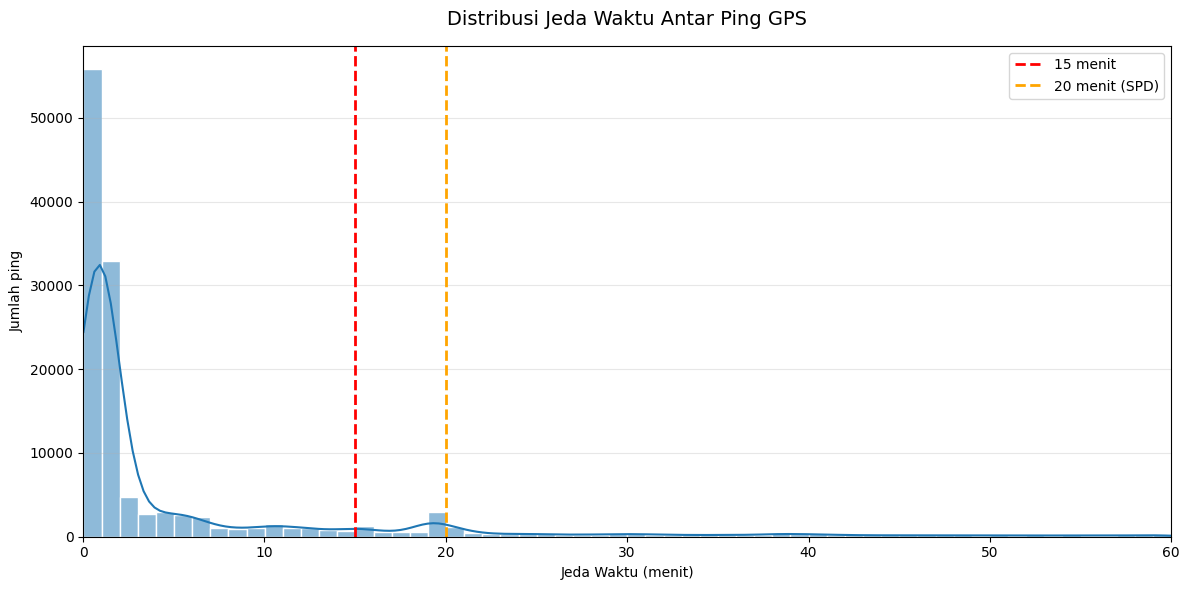

In [13]:
def compute_interping_deltas_minutes(df: pl.DataFrame, *,
                                     max_minutes: float = 60.0) -> np.ndarray:
    deltas = (
        df.sort(["maid", "timestamp"])
        .with_columns(
            (pl.col("timestamp").diff().over("maid") / 60).alias("dt_min")
        )
        .filter(
            pl.col("dt_min").is_not_null()
            & (pl.col("dt_min") > 0)
            & (pl.col("dt_min") <= max_minutes)
        )
    )
    return deltas["dt_min"].to_numpy()


def plot_interping_distribution(deltas: np.ndarray, *,
                                spd_threshold_min: float,
                                xmax: float = 60.0) -> None:
    plt.figure(figsize=(12, 6))
    sns.histplot(deltas, bins=60, kde=True, color="#1f77b4", edgecolor="white")
    plt.axvline(15, color="red", linestyle="--", linewidth=2, label="15 menit")
    plt.axvline(spd_threshold_min, color="orange", linestyle="--", linewidth=2,
                label=f"{spd_threshold_min:.0f} menit (SPD)")
    plt.title("Distribusi Jeda Waktu Antar Ping GPS", fontsize=14, pad=15)
    plt.xlabel("Jeda Waktu (menit)")
    plt.ylabel("Jumlah ping")
    plt.xlim(0, xmax)
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


deltas = compute_interping_deltas_minutes(df_candidates_collapsed, max_minutes=60.0)
plot_interping_distribution(deltas, spd_threshold_min=SPD_TIME_MIN)


---

## Stage 2 — Trajectory Segmentation (tiga metode untuk perbandingan)

Setiap metode mengeluarkan output yang sama: dua kolom `trip_id` (int per MAID,
increment setelah setiap stay point selesai) dan `is_stay_point` (bool).
Trip = ping dengan `is_stay_point=False`, dikelompokkan per `(maid, trip_id)`.

**Method A — Zheng et al. (2011).** *Mining interesting locations and travel
sequences from GPS trajectories.* Sequential greedy scan: dual threshold
(distance + time). O(N) per MAID. Ini metode utama yang disimpan ke
`OUTPUT_TRIPS` dan dipakai di stage HMM downstream.

**Method B — Birant & Kut (2007), ST-DBSCAN.** *Data & Knowledge Engineering
60(1), 208–221.* Density-based clustering dengan eps spasial **dan** eps
temporal. Cluster dengan durasi ≥ `time_thr_s` → stay point.

**Method C — Schuessler & Axhausen (2009).** *Processing raw data from
GPS without additional information. Transportation Research Record 2105,
28–36.* Velocity-based: smooth speed antar ping, dwell run dengan
speed < `v_thr` selama ≥ `time_thr_s` → stay point.

Threshold disamakan di mana mungkin (`SPD_DIST_M=100m`, `SPD_TIME_MIN=20min`)
agar selisih hasil mencerminkan **prinsip metode**, bukan tuning.

In [14]:
# ===== Method A: Zheng et al. 2011 (sequential greedy SPD) =====

def detect_zheng_2011(lat: np.ndarray, lon: np.ndarray, ts: np.ndarray, *,
                     dist_thr_m: float, time_thr_s: float
                     ) -> tuple[np.ndarray, np.ndarray]:
    """Sequential SPD per single trajectory (sorted by ts).

    Returns (trip_id, is_stay) — both length n.
    """
    n = len(lat)
    trip_id = np.zeros(n, dtype=np.int64)
    is_stay = np.zeros(n, dtype=bool)
    if n == 0:
        return trip_id, is_stay

    current_trip = 0
    i = 0
    while i < n:
        j = _zheng_find_first_outside_radius(lat, lon, i, dist_thr_m)
        cluster_size = j - i
        cluster_duration = ts[j - 1] - ts[i] if cluster_size >= 2 else 0
        is_stay_cluster = cluster_size >= 2 and cluster_duration >= time_thr_s

        trip_id[i:j] = current_trip
        if is_stay_cluster:
            is_stay[i:j] = True
            current_trip += 1
        if j == n:
            break
        i = j
    return trip_id, is_stay


def _zheng_find_first_outside_radius(lat: np.ndarray, lon: np.ndarray,
                                    anchor_idx: int, radius_m: float) -> int:
    """Smallest j > anchor_idx such that haversine(p_anchor, p_j) > radius_m. Else n."""
    n = len(lat)
    j = anchor_idx + 1
    while j < n:
        d = haversine_m(lat[anchor_idx], lon[anchor_idx], lat[j], lon[j])
        if d > radius_m:
            return j
        j += 1
    return n


In [15]:
# ===== Method B: ST-DBSCAN (Birant & Kut, 2007) =====

NOISE_LABEL = -1


def detect_stdbscan(lat: np.ndarray, lon: np.ndarray, ts: np.ndarray, *,
                   eps_s_m: float, eps_t_s: float, min_pts: int, time_thr_s: float
                   ) -> tuple[np.ndarray, np.ndarray]:
    """ST-DBSCAN per single trajectory, then convert to (trip_id, is_stay).

    A contiguous run of pings sharing the same non-noise cluster label *and*
    spanning ≥ time_thr_s is treated as a stay point.
    """
    n = len(lat)
    if n == 0:
        return np.zeros(0, dtype=np.int64), np.zeros(0, dtype=bool)
    cluster_labels = _stdbscan_cluster(lat, lon, ts, eps_s_m, eps_t_s, min_pts)
    return _segmentation_from_run_labels(cluster_labels, ts, time_thr_s, min_pts)


def _stdbscan_cluster(lat, lon, ts, eps_s_m, eps_t_s, min_pts) -> np.ndarray:
    n = len(lat)
    labels = np.full(n, NOISE_LABEL, dtype=np.int64)
    visited = np.zeros(n, dtype=bool)
    cluster_id = 0

    for seed_idx in range(n):
        if visited[seed_idx]:
            continue
        visited[seed_idx] = True
        neighbors = _spatiotemporal_neighbors(seed_idx, lat, lon, ts, eps_s_m, eps_t_s)
        if len(neighbors) < min_pts:
            continue
        labels[seed_idx] = cluster_id
        _expand_cluster(seed_idx, neighbors, cluster_id, labels, visited,
                        lat, lon, ts, eps_s_m, eps_t_s, min_pts)
        cluster_id += 1
    return labels


def _expand_cluster(seed_idx, neighbors, cluster_id, labels, visited,
                   lat, lon, ts, eps_s_m, eps_t_s, min_pts) -> None:
    queue = list(neighbors)
    while queue:
        j = queue.pop()
        if not visited[j]:
            visited[j] = True
            j_neighbors = _spatiotemporal_neighbors(j, lat, lon, ts, eps_s_m, eps_t_s)
            if len(j_neighbors) >= min_pts:
                queue.extend(j_neighbors.tolist())
        if labels[j] == NOISE_LABEL:
            labels[j] = cluster_id


def _spatiotemporal_neighbors(i: int, lat, lon, ts, eps_s_m, eps_t_s) -> np.ndarray:
    """Indices j with |t_j - t_i| ≤ eps_t_s AND haversine(p_i, p_j) ≤ eps_s_m.

    Uses binary search on the time-sorted ts array to bound the candidate set.
    """
    j_lo = np.searchsorted(ts, ts[i] - eps_t_s, side="left")
    j_hi = np.searchsorted(ts, ts[i] + eps_t_s, side="right")
    candidates = np.arange(j_lo, j_hi)
    if candidates.size == 0:
        return candidates
    distances = haversine_m(lat[i], lon[i], lat[candidates], lon[candidates])
    return candidates[distances <= eps_s_m]


def _segmentation_from_run_labels(labels: np.ndarray, ts: np.ndarray,
                                 time_thr_s: float, min_pts: int
                                 ) -> tuple[np.ndarray, np.ndarray]:
    """Walk runs of consecutive same-label pings; mark qualifying runs as stays."""
    n = len(labels)
    trip_id = np.zeros(n, dtype=np.int64)
    is_stay = np.zeros(n, dtype=bool)
    current_trip = 0
    i = 0
    while i < n:
        j = i + 1
        while j < n and labels[j] == labels[i]:
            j += 1
        run_size = j - i
        run_duration = ts[j - 1] - ts[i] if run_size >= 2 else 0
        is_dense_run = (
            labels[i] != NOISE_LABEL
            and run_size >= min_pts
            and run_duration >= time_thr_s
        )
        trip_id[i:j] = current_trip
        if is_dense_run:
            is_stay[i:j] = True
            current_trip += 1
        i = j
    return trip_id, is_stay


In [16]:
# ===== Method C: Velocity-based dwell (Schuessler & Axhausen, 2009) =====

def detect_velocity_dwell(lat: np.ndarray, lon: np.ndarray, ts: np.ndarray, *,
                         v_thr_ms: float, time_thr_s: float, smooth_window: int
                         ) -> tuple[np.ndarray, np.ndarray]:
    """Velocity-based segmentation per single trajectory.

    1. Compute instantaneous speed from haversine / dt between consecutive pings.
    2. Smooth via moving median (robust to GPS jumps).
    3. Identify maximal contiguous runs with smoothed speed < v_thr_ms.
    4. Run with duration ≥ time_thr_s → stay point.
    """
    n = len(lat)
    if n < 2:
        return np.zeros(n, dtype=np.int64), np.zeros(n, dtype=bool)

    speeds = _instantaneous_speeds(lat, lon, ts)
    smoothed = _moving_median(speeds, window=smooth_window)
    is_low_speed = smoothed < v_thr_ms

    return _segmentation_from_low_speed_runs(is_low_speed, ts, time_thr_s)


def _instantaneous_speeds(lat, lon, ts) -> np.ndarray:
    """Speed at index i = distance(i-1, i) / dt(i-1, i). Index 0 mirrors index 1."""
    distances = haversine_m(lat[:-1], lon[:-1], lat[1:], lon[1:])
    dt = np.maximum(np.diff(ts), 1.0)
    speed_pairs = distances / dt
    return np.concatenate([[speed_pairs[0]], speed_pairs])


def _moving_median(x: np.ndarray, *, window: int) -> np.ndarray:
    if window <= 1 or len(x) <= window:
        return x.copy()
    half = window // 2
    n = len(x)
    out = np.empty(n)
    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        out[i] = np.median(x[lo:hi])
    return out


def _segmentation_from_low_speed_runs(is_low_speed: np.ndarray, ts: np.ndarray,
                                      time_thr_s: float
                                      ) -> tuple[np.ndarray, np.ndarray]:
    n = len(is_low_speed)
    trip_id = np.zeros(n, dtype=np.int64)
    is_stay = np.zeros(n, dtype=bool)
    current_trip = 0
    i = 0
    while i < n:
        if not is_low_speed[i]:
            trip_id[i] = current_trip
            i += 1
            continue
        j = i
        while j < n and is_low_speed[j]:
            j += 1
        run_duration = ts[j - 1] - ts[i] if j - i >= 2 else 0
        trip_id[i:j] = current_trip
        if run_duration >= time_thr_s:
            is_stay[i:j] = True
            current_trip += 1
        i = j
    return trip_id, is_stay


In [17]:
# ===== Common dispatcher (per-MAID iteration shared across methods) =====

PerTrajectoryDetector = Callable[..., tuple[np.ndarray, np.ndarray]]


def segment_trips(df: pl.DataFrame, detector: PerTrajectoryDetector,
                  **detector_kwargs) -> pl.DataFrame:
    """Apply a per-trajectory detector to each MAID; attach trip_id + is_stay_point."""
    df_sorted = df.sort(["maid", "timestamp"])
    n_total = df_sorted.height
    trip_ids = np.empty(n_total, dtype=np.int64)
    is_stay_arr = np.empty(n_total, dtype=bool)

    offset = 0
    for sub in df_sorted.partition_by("maid", maintain_order=True):
        n = sub.height
        lat = sub["latitude"].to_numpy()
        lon = sub["longitude"].to_numpy()
        ts = sub["timestamp"].to_numpy().astype(np.float64)
        t_ids, stays = detector(lat, lon, ts, **detector_kwargs)
        trip_ids[offset:offset + n] = t_ids
        is_stay_arr[offset:offset + n] = stays
        offset += n

    return df_sorted.with_columns([
        pl.Series("trip_id", trip_ids),
        pl.Series("is_stay_point", is_stay_arr),
    ])


def summarize_segmentation(df: pl.DataFrame, *, label: str) -> dict:
    """One-line method summary; returns stats dict for downstream comparison."""
    n_pings = df.height
    n_stay = int(df["is_stay_point"].sum())
    moving = df.filter(~pl.col("is_stay_point"))
    n_trips = moving.select(["maid", "trip_id"]).unique().height
    trip_lens = (
        moving.group_by(["maid", "trip_id"]).agg(n=pl.len())["n"].to_numpy()
    )
    median_len = int(np.median(trip_lens)) if len(trip_lens) else 0

    print(f"[{label}] pings={n_pings:,}  "
          f"stay={n_stay:,} ({n_stay/n_pings:.1%})  "
          f"trips={n_trips:,}  "
          f"median_trip_len={median_len}")
    return {
        "label": label,
        "n_pings": n_pings,
        "n_stay": n_stay,
        "n_trips": n_trips,
        "trip_lens": trip_lens,
    }


In [18]:
df_trips_zheng = segment_trips(
    df_candidates_collapsed,
    detect_zheng_2011,
    dist_thr_m=SPD_DIST_M,
    time_thr_s=SPD_TIME_S,
)
stats_zheng = summarize_segmentation(df_trips_zheng, label="zheng-2011")

df_trips_dbscan = segment_trips(
    df_candidates_collapsed,
    detect_stdbscan,
    eps_s_m=SPD_DIST_M,
    eps_t_s=SPD_TIME_S,
    min_pts=DBSCAN_MIN_PTS,
    time_thr_s=SPD_TIME_S,
)
stats_dbscan = summarize_segmentation(df_trips_dbscan, label="st-dbscan")

df_trips_velocity = segment_trips(
    df_candidates_collapsed,
    detect_velocity_dwell,
    v_thr_ms=VELOCITY_THRESHOLD_MS,
    time_thr_s=SPD_TIME_S,
    smooth_window=VELOCITY_SMOOTH_WINDOW,
)
stats_velocity = summarize_segmentation(df_trips_velocity, label="velocity")

# Primary output (Zheng) → downstream HMM stage
save_parquet(df_trips_zheng, OUTPUT_TRIPS)
save_parquet(df_trips_dbscan, OUTPUT_TRIPS_DBSCAN)
save_parquet(df_trips_velocity, OUTPUT_TRIPS_VELOCITY)


[zheng-2011] pings=169,914  stay=73,004 (43.0%)  trips=8,507  median_trip_len=5
[st-dbscan] pings=169,914  stay=29,215 (17.2%)  trips=11,209  median_trip_len=5
[velocity] pings=169,914  stay=92,807 (54.6%)  trips=8,594  median_trip_len=4
  → gps_rru_trips.parquet (3.6 MB)
  → gps_rru_trips_stdbscan.parquet (3.6 MB)
  → gps_rru_trips_velocity.parquet (3.6 MB)


### Method comparison — agreement on `is_stay_point`

Tiga indikator selisih antar metode pada keputusan stay-vs-moving per ping:

- **Observed agreement** (`p_o`): proporsi ping di mana dua metode setuju.
- **Cohen's κ**: setuju yang dikoreksi terhadap chance agreement.
  Nilai 1.0 = identik, 0 = tidak lebih baik dari acak, < 0 = bertentangan.
- **Stay-fraction Δ**: |frac_stay(A) − frac_stay(B)|. Jika kecil tapi κ kecil
  juga → metode setuju di volume tapi beda di lokasi keputusan.

In [19]:
def cohens_kappa_binary(a: np.ndarray, b: np.ndarray) -> float:
    """Cohen's κ for two binary arrays (no sklearn dependency)."""
    n = len(a)
    p_o = float((a == b).mean())
    pa1 = float(a.mean())
    pb1 = float(b.mean())
    p_e = pa1 * pb1 + (1 - pa1) * (1 - pb1)
    return (p_o - p_e) / (1 - p_e) if p_e < 1 else 1.0


def compare_method_pair(df_a: pl.DataFrame, df_b: pl.DataFrame, *,
                        label_a: str, label_b: str) -> None:
    """Pairwise comparison on (maid, timestamp)-aligned is_stay_point flags."""
    join_keys = ["maid", "timestamp"]
    pair = (
        df_a.select(join_keys + ["is_stay_point"])
        .rename({"is_stay_point": "stay_a"})
        .join(
            df_b.select(join_keys + ["is_stay_point"]).rename({"is_stay_point": "stay_b"}),
            on=join_keys, how="inner",
        )
    )
    a = pair["stay_a"].to_numpy()
    b = pair["stay_b"].to_numpy()
    p_o = float((a == b).mean())
    kappa = cohens_kappa_binary(a, b)
    delta = abs(a.mean() - b.mean())
    print(f"  {label_a:>12s} vs {label_b:<12s}  "
          f"agreement={p_o:.4f}  κ={kappa:+.4f}  |Δstay-frac|={delta:.4f}")


print("=" * 64)
print("Per-method stay-fraction:")
for s in (stats_zheng, stats_dbscan, stats_velocity):
    print(f"  {s['label']:>12s}  stay_frac={s['n_stay']/s['n_pings']:.4f}  "
          f"n_trips={s['n_trips']:,}")
print("\nPairwise agreement on is_stay_point:")
compare_method_pair(df_trips_zheng, df_trips_dbscan, label_a="zheng", label_b="dbscan")
compare_method_pair(df_trips_zheng, df_trips_velocity, label_a="zheng", label_b="velocity")
compare_method_pair(df_trips_dbscan, df_trips_velocity, label_a="dbscan", label_b="velocity")


Per-method stay-fraction:
    zheng-2011  stay_frac=0.4297  n_trips=8,507
     st-dbscan  stay_frac=0.1719  n_trips=11,209
      velocity  stay_frac=0.5462  n_trips=8,594

Pairwise agreement on is_stay_point:
         zheng vs dbscan        agreement=0.7380  κ=+0.4227  |Δstay-frac|=0.2577
         zheng vs velocity      agreement=0.8574  κ=+0.7185  |Δstay-frac|=0.1165
        dbscan vs velocity      agreement=0.6214  κ=+0.2861  |Δstay-frac|=0.3743


---

## Stage 2b — Drop short trips + drop singleton MAID (primary method)

Trip dengan < `MIN_PINGS_PER_TRIP` ping tidak bisa dipakai untuk HMM —
minimal butuh start, mid, end untuk estimasi heading & transition.
Diterapkan ke **Method A (Zheng-2011)** sebagai output utama.

In [20]:
df_trips_moving = df_trips_zheng.filter(~pl.col("is_stay_point"))
df_trips_moving = drop_short_trips(df_trips_moving, min_pings=MIN_PINGS_PER_TRIP)
df_trips_moving = drop_singleton_maids(df_trips_moving)
log_state(df_trips_moving, label="stage 2b", trip_keys=("maid", "trip_id"))


[stage 2b] pings=92,583  maids=4,469  trips=6,028


In [21]:
trip_ping_counts = (
    df_trips_moving
    .group_by(["maid", "trip_id"])
    .agg(n_pings=pl.len())
)

print(
    trip_ping_counts
    .group_by("n_pings")
    .agg(jumlah_trip=pl.len())
    .sort("n_pings")
)
print(f"Total trip      : {trip_ping_counts.height:,}")
print(f"Mean ping/trip  : {trip_ping_counts['n_pings'].mean():.2f}")
print(f"Median ping/trip: {trip_ping_counts['n_pings'].median():.0f}")


shape: (141, 2)
┌─────────┬─────────────┐
│ n_pings ┆ jumlah_trip │
│ ---     ┆ ---         │
│ u32     ┆ u32         │
╞═════════╪═════════════╡
│ 3       ┆ 918         │
│ 4       ┆ 687         │
│ 5       ┆ 433         │
│ 6       ┆ 390         │
│ 7       ┆ 338         │
│ …       ┆ …           │
│ 182     ┆ 1           │
│ 186     ┆ 1           │
│ 190     ┆ 1           │
│ 193     ┆ 1           │
│ 210     ┆ 1           │
└─────────┴─────────────┘
Total trip      : 6,028
Mean ping/trip  : 15.36
Median ping/trip: 8
